Exploración y perfilamiento de los datos, utilizando las funcionalidades de la librería pandas. Recuerda que este paso es muy importante para determinar problemas de calidad (por ejemplo, valores ausentes y registros duplicados) y tomar decisiones relacionadas con la preparación de los datos para el algoritmo de aprendizaje. 

Construcción del pipeline de limpieza y preparación de los datos, justificando las decisiones tomadas con base en los resultados obtenidos en el paso anterior.

Construcción de un modelo de árboles de decisión. Utiliza la función GridSeacrhCV, con el siguiente espacio de búsqueda: {'criterion':['gini', 'entropy'],'max_depth':[4,6,8,10,12],'min_samples_split':[3, 4, 5]}. 

Construcción de un modelo utilizando el algoritmo K-vecinos más cercanos. Para determinar el número de vecinos utiliza los siguientes valores de K: [1, 2, 3, 4, 5].

Elaboración de una tabla comparativa mostrando el rendimiento sobre test de los dos modelos seleccionados (con mejores rendimientos) de las actividades 3 y 4, sobre las métricas exactitud, recall, precisión y F-score. 

Estimación de intervalos de confianza mediante bootstrapping. Investiga la técnica de bootstrapping y utilízala para estimar un intervalo de confianza del 95% para al menos una de las métricas (por ejemplo, exactitud) con base en el modelo de mejor desempeño. Debes explicar brevemente el procedimiento utilizado e interpretar el intervalo obtenido en el contexto del problema.

Utilizando el modelo de árboles de decisión, hasta con una profundidad de tres (3), genera las reglas que permitan determinar cuándo un paciente está en riesgo de sufrir hipertensión (no es necesario volver a construir el árbol).

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from importlib.metadata import version
from sklearn.tree import DecisionTreeClassifier

In [80]:
ruta = r'C:\Users\WINDOWS\Documents\MAIA\Proyecto_2\data_hipertension_raw.csv'
data_raw = pd.read_csv(ruta, encoding = 'latin1', sep = ';')

In [81]:
data_raw.head(5)

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


In [82]:
data = data_raw.copy()

In [83]:
data.isna().sum()

Edad                  0
Ingesta_Sal           0
Nivel_Stres           0
Colesterol            0
Duración_Sueño        0
BMI                   0
Medicación            0
Historia_Familiar     0
Actividad_Fisica      0
Fumador               0
Glucosa               0
Enfermedad_Corazon    0
Hipertension          0
dtype: int64

In [84]:
data = data.drop_duplicates()


In [85]:
data.info()

<class 'pandas.DataFrame'>
Index: 1986 entries, 0 to 1989
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                1986 non-null   int64  
 1   Ingesta_Sal         1986 non-null   float64
 2   Nivel_Stres         1986 non-null   int64  
 3   Colesterol          1986 non-null   float64
 4   Duración_Sueño      1986 non-null   float64
 5   BMI                 1986 non-null   float64
 6   Medicación          1986 non-null   str    
 7   Historia_Familiar   1986 non-null   str    
 8   Actividad_Fisica    1986 non-null   str    
 9   Fumador             1986 non-null   str    
 10  Glucosa             1986 non-null   float64
 11  Enfermedad_Corazon  1986 non-null   str    
 12  Hipertension        1986 non-null   str    
dtypes: float64(5), int64(2), str(6)
memory usage: 262.4 KB


Se encuentran 6 variables categoricas (dtype):
Historia familiar, Actividad_Fisica, Fumador, Enfermedad_Corazon, Hipertension, Medicación.

Dos variables tipo int: Edad, Nivel_estres.

Cinco variables tipo float: Ingesta_sal, Colesterol, Duracion_sueño, BMI, Glucosa. 

In [86]:
data.describe()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Glucosa
count,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000
mean,50.353474,8.531923,4.978852,209.521349,6.452064,26.014904,105.638872
std,19.445019,1.994433,3.141588,75.857205,1.541839,4.511757,22.552453
min,18.000000,2.500000,0.000000,121.200000,1.500000,11.900000,70.000000
25%,34.000000,7.200000,2.000000,181.300000,5.400000,23.000000,89.200000
50%,50.000000,8.500000,5.000000,204.400000,6.500000,25.900000,102.500000
75%,67.000000,9.900000,8.000000,231.700000,7.500000,29.100000,119.875000
max,84.000000,16.400000,10.000000,2360.000000,11.400000,41.900000,196.100000


**Observaciones**
- **Edad:** Se encuentran pacientes con rango de edad entre 18 a 84 años.
- **Ingesta de sal:** En el diccionario se indica esta variable en 3 categorias no numericas: Baja, Media y Alta. Es necesario decidir como se clasificaran los datos de esta variable.
- **Nivel_estres:** Variable de autopercepción con asignación numérica en escala [1, 10] (cuantificación de una percepción cualitativa). Por consiguiente, debe tomarse con cuidado en el analisis.
- **Colesterol:** Las unidades parecen coherentes con mg/dL que es el estándar habitual.

  Se observan valores atípicos significativos. Bajo el criterio IQR, se esperaría un máximo aproximado de 307.3 mg/dL.  
  Sin embargo, un valor reportado de 2360 mg/dL es clínicamente implausible (de acuerdo con bibliografia medica) y sugiere error de medición/registro; se debe revisar si existen más registros de este tipo y decidir como se trataran estos datos. 

- **Duracion de sueño:** Se evidencian datos entre [1.5, 11] horas. 
  Datos correspondientes a pocas horas, ya que son un reporte de horas de sueño promedio son biologicamente inconsistentes. 
- **BMI:** Valores observados en el rango [12, 42].
   De acuerdo con la literatura médica, los outliers encontrados corresponden con valores posibles (peso bajo grave, obesidad morbida). 
- **Glucosa:** Los datos coinciden con unidades de mg/dL, medición estandar. 

<function matplotlib.pyplot.show(close=None, block=None)>

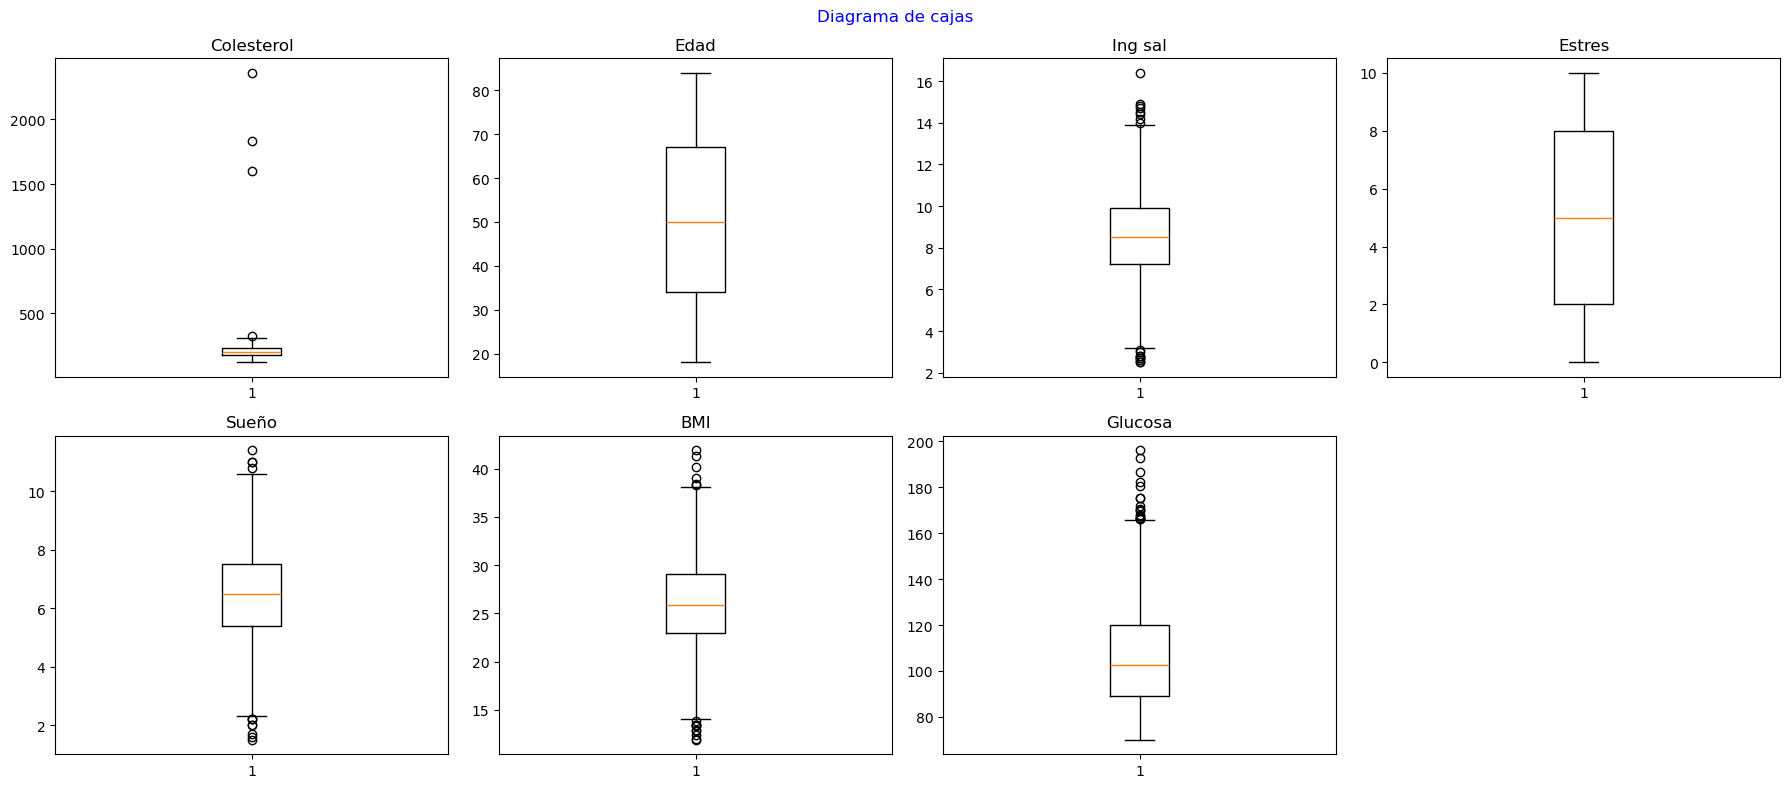

In [87]:
plt.figure(figsize=(18,8))
plt.subplot(241)
plt.boxplot(data['Colesterol'])
plt.title('Colesterol')
plt.subplot(242)
plt.boxplot(data['Edad'])
plt.title('Edad')
plt.subplot(243)
plt.boxplot(data['Ingesta_Sal'])
plt.title('Ing sal')
plt.subplot(244)
plt.boxplot(data['Nivel_Stres'])
plt.title('Estres')
plt.subplot(245)
plt.boxplot(data['Duración_Sueño'])
plt.title('Sueño')
plt.subplot(246)
plt.boxplot(data['BMI'])
plt.title('BMI')
plt.subplot(247)
plt.boxplot(data['Glucosa'])
plt.title('Glucosa')
plt.suptitle('Diagrama de cajas',color ='b')
plt.tight_layout()
plt.show

Se evidencian multiples valores atipicos en diferentes categorias. Sin embargo, dado que son datos medicos es posible que existan legitimamente valores extremos. Los unicas variables donde se realizaran cambios en el caso de Colesterol y Horas de sueño.

In [88]:
data[data['Colesterol'] > 307]

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
12,81,11.0,9,2360.0,8.4,17.3,Ninguna,Si,Baja,No,93.0,No,Si
16,75,9.0,4,1597.0,6.1,25.2,Ninguna,No,Alta,No,92.8,No,No
196,19,9.5,6,1835.0,5.3,33.5,Otro,Si,Alta,No,95.1,No,No
211,53,9.4,4,326.3,6.7,22.1,Otro,No,Moderada,No,119.7,No,Si


Dado que los valores atipicos son solo 4 registros, puede deberse a errores de medición y por tanto se decide eliminarlas para evitar distorsiones en el modelo. 

In [89]:
data = data[data['Colesterol'] <= 307]

De acuerdo con la literatura consultada, las funciones vitales del cuerpo necesitan de un promedio de horas de sueño mínimo. Se han identificado casos geneticos donde es posible registrar 4 hroas de sueño promedio sin afectacion sobre la salud. Por ende, se decidio eliminar los registros menores a 3.5 hroas reportadas.

In [90]:
data = data[data['Duración_Sueño'] < 3.5]

**Datos categoricos**

In [91]:
data.describe(include= object)

C:\Users\WINDOWS\AppData\Local\Temp\ipykernel_14032\3673245348.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include= object)


,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Enfermedad_Corazon,Hipertension
count,49,49,49,49,49,49
unique,5,2,3,2,2,2
top,Ninguna,Si,Moderada,No,No,Si
freq,16,28,21,35,36,37


In [92]:
data['Medicación'].unique()

<ArrowStringArray>
['Ninguna', 'InhibidorACE', 'BloqueadorBeta', 'Diuretico', 'Otro']
Length: 5, dtype: str

In [14]:
for col in ['Medicación', 'Historia_Familiar', 'Actividad_Fisica']:
    print(data[col].value_counts())

Medicación
Ninguna           800
BloqueadorBeta    412
InhibidorACE      323
Diuretico         245
Otro              206
Name: count, dtype: int64
Historia_Familiar
No    1001
Si     985
Name: count, dtype: int64
Actividad_Fisica
Baja        936
Moderada    658
Alta        392
Name: count, dtype: int64


In [15]:
for col in ['Fumador', 'Enfermedad_Corazon', 'Hipertension']:
    print(data[col].value_counts())

Fumador
No    1418
Si     568
Name: count, dtype: int64
Enfermedad_Corazon
No    1511
Si     475
Name: count, dtype: int64
Hipertension
Si    1032
No     954
Name: count, dtype: int64


In [125]:
data.columns

Index(['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño',
       'BMI', 'Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador',
       'Glucosa', 'Enfermedad_Corazon', 'Hipertension'],
      dtype='str')

In [126]:
encoder = OneHotEncoder(sparse_output=False)
scaler = RobustScaler()
numerical = ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño','BMI', 'Glucosa']
categorical = ['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador','Enfermedad_Corazon']

In [127]:
preprocess_arbol = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical),
        ('cat', encoder, categorical),
    ],
    verbose_feature_names_out=False
)

In [112]:
preprocess_kmeans = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', encoder, categorical),
    ],
    verbose_feature_names_out=False
)

In [128]:
train,test = train_test_split(data,test_size=0.2,random_state=77)

In [129]:
x_train = train.drop(['Hipertension'],axis=1)
y_train = train['Hipertension']

In [130]:
decision_tree = DecisionTreeClassifier(random_state=77)
steps = [
    ('transformer',preprocess_arbol),
    ('model',decision_tree),
]
pipeline = Pipeline(steps).set_output(transform='pandas')

In [131]:
param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [4, 6, 8, 10, 12],
    'model__min_samples_split': [3, 4, 5],
}

In [132]:
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

In [133]:
grid = GridSearchCV(pipeline, param_grid, cv=kfold)

In [134]:
grid.fit(x_train, y_train)

c:\Users\WINDOWS\anaconda3\envs\maia\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\WINDOWS\anaconda3\envs\maia\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\WINDOWS\anaconda3\envs\maia\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\WINDOWS\anaconda3\envs\maia\Lib\site-packages\sklearn\pipeline.py", line 1131, in score
    Xt = transform.transform(Xt)
  File "c:\Users\WINDOWS\anaconda3\envs\maia\Lib\site-packages\sklearn\utils\_set_output.py", line 316, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
  File "c:\Users\WINDOWS\anaconda3\envs\maia\Lib\site-pack

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=77))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [4, 6, ...], 'model__min_samples_split': [3, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [135]:
print("Mejores parámetros: {}".format(grid.best_params_))

Mejores parámetros: {'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_split': 3}


In [136]:
mejor_pipeline = grid.best_estimator_
mejor_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [140]:
x_test = test.drop(['Hipertension'],axis=1)
y_test = test['Hipertension']

In [141]:
y_test_pred = mejor_pipeline.predict(x_test)

In [144]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

          No       0.00      0.00      0.00         2
          Si       0.75      0.75      0.75         8

    accuracy                           0.60        10
   macro avg       0.38      0.38      0.38        10
weighted avg       0.60      0.60      0.60        10



In [ ]:
k_means = KNeighborsClassifier()
steps = [
    ('transformer',preprocess_kmeans),
    ('model',k_means),
]

In [ ]:
train_scores, val_scores = validation_curve(
    estimator = KNeighborsClassifier(),
    X = x_train,
    y = y_train,
    param_name = 'n_neighbors',
    param_range = k_values,
    scoring = 'accuracy',
    cv = 10
)